#### Final: Candice Ye (sy348)

In [144]:
import Exam as exam
import numpy as np
import pandas as pd
import math
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.stats import t, norm, multivariate_normal, skew, kurtosis, gaussian_kde, spearmanr, rankdata
import statsmodels.miscmodels.tmodel as tmodel
from statsmodels.stats.correlation_tools import cov_nearest, corr_nearest
import matplotlib.pyplot as plt
from scipy.optimize import brentq

**1.a. What is the price of a put and a call when the Strike ∈ [99,100,101]**

In [145]:
data1 = pd.read_csv("problem1.csv").values.flatten()
data1

array([0.00174025, 0.00905899, 0.00018302, ..., 0.00025865, 0.00420047,
       0.00022642])

In [146]:
S0 = 100
r = 0.04
T = 1 / 255
discount = np.exp(-r * T)

ST = S0 * (1 + data1)

strikes = [99, 100, 101]
rows = []

for K in strikes:
    call_price = discount * np.mean(np.maximum(ST - K, 0))
    put_price = discount * np.mean(np.maximum(K - ST, 0))
    rows.append([K, call_price, put_price])

output = pd.DataFrame(rows, columns=['Strike', 'Call Price', 'Put Price'])
output

,Strike,Call Price,Put Price
0,99,1.041951,0.026424
1,100,0.194572,0.178888
2,101,0.012274,0.996433


**1.b. Graph the implied volatility of call option prices using BSM along the range of strikes between [98,102]**

In [147]:
# Implied volatility from Monte Carlo to BSM
def bs_call_price(S, K, r, T, trading_days, sigma):
    TTM = T / trading_days
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * TTM) / (sigma * np.sqrt(TTM))
    d2 = d1 - sigma * np.sqrt(TTM)
    return S * norm.cdf(d1) - K * np.exp(-r * TTM) * norm.cdf(d2)


def implied_volatility(returns, S0, r, T, trading_days, strike_grid, sigma_low=1e-6, sigma_high=5.0):
    ST = S0 * (1 + returns)
    TTM = T / trading_days

    call_prices = []
    implied_vols = []

    for K in strike_grid:
        call_price = np.exp(-r * TTM) * np.mean(np.maximum(ST - K, 0))
        objective = lambda sigma: bs_call_price(S0, K, r, T, trading_days, sigma) - call_price
        implied_vol = brentq(objective, sigma_low, sigma_high)

        call_prices.append(call_price)
        implied_vols.append(implied_vol)

    return implied_vols

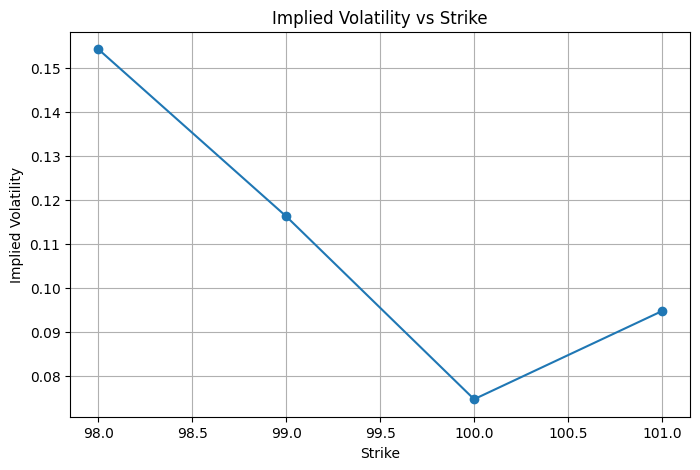

In [148]:
strike_grid = np.arange(98, 102)

implied_vols = implied_volatility(
    returns=data1,
    S0=100,
    r=0.04,
    T=1,
    trading_days=255,
    strike_grid=strike_grid
)

plt.figure(figsize=(8, 5))
plt.plot(strike_grid, implied_vols, marker="o")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Implied Volatility vs Strike")
plt.grid(True)
plt.show()

**1.c. Discuss: Theory would say this should be a flat line. Why is it not?**

In [149]:
skewness = skew(data1)
kurt = kurtosis(data1)

print(skewness, kurt)

-1.086563249385968 8.733191071516128


The simulated returns are negatively skewed and exhibit excess kurtosis. BSM theory assumes lognormal returns and constant volatility, but simulated return won't be exact lognormal.

**2.a. What is the holding period Sharpe Ratio of each asset?**

In [150]:
data2 = pd.read_csv("problem2.csv")
data2

,a,b,c
0,0.068992,0.090322,-0.222463
1,0.113488,0.138645,-0.616300
2,0.180086,0.217307,0.404441
3,-0.190042,-0.210383,0.020422
4,-0.018018,0.000147,0.616983
...,...,...,...
995,0.036894,0.057096,0.525503
996,-0.095151,-0.085575,0.301591
997,-0.108815,-0.102708,0.009846
998,0.200875,0.246184,0.608856


In [151]:
rf = math.sqrt(1.04) - 1   # risk free rate to 6 months

for asset in data2.columns:
    ret = data2[asset].values
    
    mu = np.mean(ret)
    risk_premium = mu - rf
    vol = np.std(ret, ddof=1)
    sharpe = risk_premium / vol
    print(asset, sharpe)

a 0.11316707133597241
b 0.2792425528074317
c 0.8890849245906918


**2.b. Find the maximum Sharpe Ratio portfolio. Weights can be in [-1,1]**

In [152]:
cov = data2.cov()
mu = data2.mean()

In [153]:
# Max SR portfolio
max_sr_weights = exam.normal_max_sharpe(cov.values, mu.values, rf, weights_lb=-1, weights_ub=1)
max_sr_weights

array([-0.5583941,  1.       ,  0.5583941])

**2.c. Explain the weights. Consider the correlations and Sharpe Ratios of the assets**

In [154]:
corr = data2.corr()
corr

,a,b,c
a,1.000000,0.995976,-0.080461
b,0.995976,1.000000,-0.077787
c,-0.080461,-0.077787,1.000000


We're shorting 56% a, longing 100% b, and longing 56% c. Looking at the correlation, a and b almost have an 100% correlation, meaning their prices tightly move together and it's not beneficial to hold them both in the portfolio. The Sharpe ratio of c is bigger than that of b, then bigger than that of a. Therefore, giving b and c more weights can effectively increase the portfolio returns, while moving a and b in 2 different holding directions can effectively reduce risk.

**2.d. Now use the simulated values, and Expected Shortfall as the risk measure to find the optimal portfolio for (E(r)- rf) / ES**

In [155]:
# Max Sharpe ratio (return-to-risk) helper
def portfolio_volatility(w, cov):
    cov = make_psd_cov(cov)
    return np.sqrt(w @ cov @ w)

def portfolio_expected_shortfall(w, sim_returns, alpha=0.05):
    _, port_es = exam.var_es_hist_sim(sim_returns @ w, alpha)
    return port_es

def solve_max_return_to_risk(
    exp_returns,
    risk_fun,
    n_assets,
    risk_args=(),
    rf=0.0,
    w0=None,
    bounds=None,
    ftol=1e-9,
    maxiter=1000,
):
    if w0 is None:
        w0 = np.ones(n_assets) / n_assets

    if bounds is None:
        bounds = [(0, 1)] * n_assets

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    def objective(w):
        port_mean = w @ exp_returns
        port_risk = risk_fun(w, *risk_args)
        return -(port_mean - rf) / port_risk

    result = minimize(
        objective,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': ftol, 'maxiter': maxiter}
    )

    w_opt = result.x
    port_mean = w_opt @ exp_returns   # portfolio expected returns (mean)
    port_risk = risk_fun(w_opt, *risk_args)   # portfolio vol
    ratio = (port_mean - rf) / port_risk   # Sharpe ratio

    return w_opt

In [156]:
# Max Sharpe ratio optimization using ES
def es_max_sharpe(returns, rf, alpha, weights_lb, weights_ub):
    n_assets = returns.shape[1]
    bounds = [(-1, 1)] * n_assets

    result = solve_max_return_to_risk(
        exp_returns=mu,
        risk_fun=portfolio_expected_shortfall,
        n_assets=n_assets,
        risk_args=(returns, alpha),
        rf=rf,
        bounds=bounds,
        ftol=1e-12,
        maxiter=2000,
    )

    return result

In [157]:
sr_weights = es_max_sharpe(data2, rf, alpha=0.05, weights_lb=-1, weights_ub=1)
sr_weights

array([-0.34764008,  1.        ,  0.34764008])

**2.e. Discuss the weights. Why do they differ from the max Sharpe Ratio weights?**

In [158]:
skewness = skew(data2.values)

print(skewness)

[ 0.15080811  0.27780144 -0.67594777]


We can see that returns of c has negative skewness, which represents a bigger investment risk. ES incorporates this long tail, giving less weight to c and more weight to a. Standard deviation doesn't capture that.

**2.f. Calculate the risk parity portfolio based on the simulation and ES. Report the weights and the Contribution to
ES for each asset**

In [159]:
# ES Risk parity
def es_risk_parity_equal_w(returns, alpha):
    n_assets = returns.shape[1]
    
    w, rc, res = exam.solve_risk_parity(
        component_fun=exam.component_es,
        n_assets=n_assets,
        args=(returns, alpha, 1e-6),
        budget_vec=np.ones(n_assets),
        ftol=1e-12,
        maxiter=2000,
        scale=1.0
    )
        
    return w

In [160]:
rp_weights = es_risk_parity_equal_w(data2, 0.05)
rp_weights

array([0.43733156, 0.34980333, 0.21286511])

**2.g. Calculate the return and risk ex-ante attribution of the portfolio from part d. Compare to the return and risk exante
attribution of the risk parity portfolio. Discuss**

In [161]:
# d: Sharpe ratio
ret_attr, ret_attr_pct, vol_attr, vol_attr_pct = exam.exp_attribution(sr_weights, mu.values, cov.values)

In [162]:
ret_df = pd.DataFrame({
    "Asset": data2.columns,
    "Expected_Return_Attribution": ret_attr,
    "Expected_Return_Attrib_Pct": ret_attr_pct
})

ret_df

,Asset,Expected_Return_Attribution,Expected_Return_Attrib_Pct
0,a,-0.010807,-0.078347
1,b,0.051885,0.376131
2,c,0.096866,0.702216


In [163]:
vol_df = pd.DataFrame({
    "Asset": data2.columns,
    "Expected_Vol_Attribution": vol_attr,
    "Expected_Vol_Attrib_Pct": vol_attr_pct
    })

vol_df

,Asset,Expected_Vol_Attribution,Expected_Vol_Attrib_Pct
0,a,-0.019962,-0.160513
1,b,0.066964,0.538461
2,c,0.077360,0.622051


In [164]:
# f: Risk parity
ret_attr2, ret_attr_pct2, vol_attr2, vol_attr_pct2 = exam.exp_attribution(rp_weights, mu.values, cov.values)

In [165]:
ret_df2 = pd.DataFrame({
    "Asset": data2.columns,
    "Expected_Return_Attribution": ret_attr2,
    "Expected_Return_Attrib_Pct": ret_attr_pct2
})

ret_df2

,Asset,Expected_Return_Attribution,Expected_Return_Attrib_Pct
0,a,0.013596,0.149309
1,b,0.018149,0.199318
2,c,0.059313,0.651373


In [166]:
vol_df2 = pd.DataFrame({
    "Asset": data2.columns,
    "Expected_Vol_Attribution": vol_attr2,
    "Expected_Vol_Attrib_Pct": vol_attr_pct2
    })

vol_df2

,Asset,Expected_Vol_Attribution,Expected_Vol_Attrib_Pct
0,a,0.034252,0.342086
1,b,0.031627,0.315867
2,c,0.034248,0.342047


In the risk parity portfolio, the volatility attribution of 3 assets are almost the same, because this is a risk parity portfolio with equal weights given to each asset. In the max Sharpe ratio portfolio, the return and volatility attributions of a are negative, meaning a is used as a hedge to reduce portfolio risk. This aligns with the correlations and Sharpe ratios of the assets we saw earlier, because a has the smallest Sharpe ratio and is highly correlated with b.

**3. What conditions are necessary for a risk parity portfolio and a maximum Sharpe Ratio portfolio to be the same?
Show it using an example with 3 assets**

If all correlations are equal and all Sharpe Ratios are equal, then the Risk Parity portfolio is also the Maximum Sharpe Ratio portfolio.

In [167]:
# Sharpe ratio: a = b = c = 1/3
rf3 = 0.0
mu3 = [1/3, 1/3, 1/3]
vol3 = [1, 1, 1]

for i in range(0, len(mu3)):
    sharpe = (mu3[i] - rf3) / vol3[i]
    print(sharpe)

0.3333333333333333
0.3333333333333333
0.3333333333333333


In [168]:
# Correlation among a, b, and c: 1/3
corr3 = [[1/3,  1/3, 1/3],
       [1/3,  1/3, 1/3],
       [1/3,  1/3, 1/3]]

In [169]:
D = np.diag(vol3)
cov3 = D @ corr3 @ D
cov3

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [170]:
# Risk parity portfolio weights
exam.normal_risk_parity_equal_w(cov3)

array([0.33333333, 0.33333333, 0.33333333])

In [171]:
# max Sharpe ratio portfolio weights
def negative_sharpe(w, mu, cov, rf):
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    return -(ret - rf) / vol

def max_sharpe_pos_w(mu, cov, rf):
    n = len(mu)
    w0 = np.ones(n) / n

    bounds = [(0, 1)] * n  # w > 0
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    result = minimize(
        negative_sharpe,
        w0,
        args=(mu, cov, rf),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    final_weights = result.x

    for weight in final_weights:
        print(weight)

max_sharpe_pos_w(mu3, cov3, rf3)

0.3333333333333333
0.3333333333333333
0.3333333333333333


We can see that when assets have the same correlation and Sharpe ratio, they are given the same weights in both portfolios.